In [11]:
# ============================================================
# CELL 1: Import Libraries
# ============================================================

import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [12]:
# ------------------------------------------------------------
# 1) Paste the CSV data directly (MANUAL EMBED)
# ------------------------------------------------------------
csv_text = """time (seconds),x,y,z
6.111,0,0,-1023
6.213,0,0,-1023
6.316,0,0,-1023
6.419,-1023,-33,33
6.523,41,153,-1011
6.622,166,149,-999
6.723,158,158,-999
6.825,158,158,-999
6.932,158,158,-999
7.031,158,158,-999
7.144,158,158,-999
7.244,158,158,-999
7.347,158,158,-999
7.45,158,158,-999
7.553,158,158,-999
7.656,158,158,-999
7.759,158,158,-999
7.862,158,158,-999
7.965,158,158,-999
8.068,158,158,-999
8.183,158,158,-999
8.286,158,158,-999
8.389,158,158,-999
8.49,158,158,-999
8.595,158,158,-999
8.698,158,158,-999
8.807,158,158,-999
8.91,158,158,-999
9.024,158,158,-999
9.128,158,158,-999
9.231,158,158,-999
9.334,158,158,-999
9.435,158,158,-999
9.54,158,158,-999
9.641,158,158,-999
9.746,158,158,-999
9.847,158,158,-999
9.947,158,158,-999
10.056,158,158,-999
10.159,158,158,-999
10.262,158,158,-999
10.363,158,158,-999
10.468,158,158,-999
10.571,158,158,-999
10.674,215,136,-991
10.777,-125,184,-999
10.88,-3,249,-993
10.983,308,176,-960
11.086,-42,230,-996
11.189,280,192,-966
11.292,475,202,-884
11.394,-589,341,-764
11.498,659,351,-700
11.601,-173,418,-918
11.701,-568,470,-710
11.802,988,427,334
11.904,-1023,408,408
12.008,-112,472,-901
12.109,812,399,-478
12.213,-1023,361,361
12.314,539,448,-746
12.42,-314,458,-860
12.523,-1023,342,342
12.623,1023,370,370
12.725,-854,366,-429
12.826,-619,334,-743
12.929,972,333,95
13.032,-1023,295,295
13.135,316,387,-893
13.236,301,366,-907
13.336,-1023,323,323
13.438,1023,333,333
13.541,-1023,238,238
13.644,-75,324,-968
13.747,187,362,-939
13.85,-869,210,-498
13.95,1023,380,380
14.056,-596,341,-759
14.159,-542,298,-815
14.262,1023,342,342
14.363,-1023,267,267
14.468,614,258,-777
14.571,734,248,-669
14.672,-1023,191,191
14.777,1023,220,220
14.878,-1023,126,126
14.983,-447,74,-918
15.086,1023,154,154
15.187,-1023,79,79
15.292,505,166,-875
15.395,578,174,-826
15.499,-936,116,-397
15.601,1023,220,220
15.702,-1023,116,116
15.807,457,237,-885
15.911,758,295,-621
16.011,-1023,257,257
16.116,1023,238,238
16.22,409,241,-907
16.323,-1023,201,201
16.423,1023,163,163
16.529,-73,150,-1010
16.631,-1023,79,79
16.733,1023,70,70
16.838,-603,99,-821
16.938,-445,73,-919
17.039,869,74,-535
17.141,-983,43,-280
17.244,505,124,-881
17.344,869,122,-526
17.448,-1023,-14,14
17.553,1023,98,98
17.653,738,70,-705
17.758,-1023,-61,61
17.862,1023,-52,52
17.965,252,-72,-989
18.068,-888,-107,-497
18.171,1023,-42,42
18.274,-978,-133,-269
18.374,39,-77,-1020
18.474,869,-20,-540
18.575,-1023,-191,191
18.68,1023,-80,80
18.783,869,-68,-536
18.884,-1023,-275,275
18.989,1023,-173,173
19.092,-119,-223,-992
19.195,-782,-302,-587
19.297,1023,-163,163
19.401,-1023,-303,303
19.504,759,-144,-671
19.607,869,-114,-528
19.71,-1023,-321,321
19.812,1023,-154,154
19.917,-25,-246,-993
20.02,-823,-330,-511
20.122,1023,-135,135
20.226,-1023,-312,312
20.329,12,-233,-997
20.432,797,-182,-615
20.534,-1023,-321,321
20.638,-1023,-405,405
20.74,-909,-423,-204
20.841,-584,-419,-728
20.942,-555,-417,-752
21.043,-690,-430,-621
21.153,-569,-409,-746
21.256,-569,-409,-746
21.363,-569,-409,-746
21.468,-569,-409,-746
21.574,-569,-409,-746
21.674,-569,-409,-746
21.79,-569,-409,-746
21.892,-569,-409,-746
21.995,-554,-418,-752
22.098,-554,-418,-752
22.214,-554,-418,-752
22.316,-554,-418,-752
22.419,-554,-418,-752
22.522,-554,-418,-752
22.625,-554,-418,-752
22.727,-554,-418,-752
22.829,-547,-427,-752
22.93,-547,-427,-752
23.035,-547,-427,-752
23.141,-547,-427,-752
23.25,-547,-427,-752
23.352,-547,-427,-752
23.456,-547,-427,-752
23.558,-547,-427,-752
23.662,-547,-427,-752
23.763,-547,-427,-752
23.868,-547,-427,-752
23.968,-547,-427,-752
24.072,-547,-427,-752
24.177,-547,-427,-752
24.284,-547,-427,-752
24.389,-547,-427,-752
24.495,-547,-427,-752
24.595,-547,-427,-752
24.705,-547,-427,-752
24.804,-547,-427,-752
24.92,-547,-427,-752
25.025,-547,-427,-752
25.128,-555,-427,-746
25.229,-563,-427,-740
25.33,-547,-427,-752
25.432,79,-307,-973
25.544,149,-304,-966
25.644,141,-304,-967
25.745,110,-302,-972
25.848,-91,-309,-971
25.953,-115,-311,-968
26.056,-115,-311,-968
26.159,-115,-311,-968
26.262,-115,-311,-968
26.365,-115,-311,-968
26.466,-115,-311,-968
26.571,-115,-311,-968
26.673,-186,-353,-942
26.777,-186,-353,-942
26.88,-186,-353,-942
26.983,-186,-353,-942
27.086,-186,-353,-942
27.198,-186,-353,-942
27.304,-186,-353,-942
27.41,-186,-353,-942
27.51,-186,-353,-942
27.623,-186,-353,-942
27.728,-186,-353,-942
27.838,-186,-353,-942
27.939,-186,-353,-942
28.041,-186,-353,-942
28.147,-186,-353,-942
28.25,-186,-353,-942
28.353,-202,-353,-939
28.465,-202,-353,-939
28.571,-209,-354,-937
28.683,-209,-354,-937
28.783,-209,-354,-937
28.884,-209,-354,-937
28.989,-209,-354,-937
29.092,-209,-354,-937
29.195,-209,-354,-937
29.298,-209,-354,-937
29.401,-209,-354,-937
29.504,-209,-354,-937
29.607,-163,-352,-947
29.71,124,-339,-958
29.812,109,-339,-960
29.916,62,-336,-965
30.018,62,-336,-965
30.129,62,-336,-965
30.229,70,-336,-964
30.335,70,-336,-964
30.438,-463,-268,-872
30.54,-869,-193,-505
30.641,1023,-182,182
30.741,875,-386,-364
30.844,477,-261,-867
30.944,670,-213,-744
31.05,-241,-410,-906
31.151,869,-268,-469
31.252,-368,-495,-817
31.353,869,-287,-458
31.456,-607,-552,-612
31.571,869,-262,-472
31.674,238,-347,-933
31.775,869,-238,-485
31.88,650,-316,-724
31.981,869,-238,-485
32.086,675,-436,-634
32.188,869,-333,-425
32.292,663,-413,-661
32.396,-78,-759,-682
32.499,1023,-511,511
32.601,-987,-942,902
32.702,976,-957,906
32.805,173,-1023,173
32.907,1023,-987,987
33.008,166,-1023,166
33.11,1023,-1023,1023
33.209,989,-1023,989
33.31,1023,-1023,1023
33.41,243,-1023,243
33.51,1023,-1023,1023
33.613,1023,-1023,1023
33.716,738,-738,0
33.819,1023,-1023,1023
33.921,738,-738,0
34.03,532,-532,-694
34.132,384,-384,-867
34.231,277,-277,-946
34.332,199,-199,-984
34.432,203,-440,-901
34.535,608,-255,-783
34.635,869,-320,-435
34.74,627,-231,-775
34.844,-761,-904,591
34.947,346,630,-728
35.05,988,-609,548
35.153,-502,-182,-873
35.256,916,-452,-57
35.358,-339,-1023,339
35.459,40,540,-868
35.56,224,-666,-744
35.662,-1011,285,238
35.765,1023,239,239
35.868,-115,-546,-858
35.97,-307,675,-705
36.074,1023,-405,405
36.175,-689,-447,-610
36.277,833,443,-396
36.377,751,-572,-395
36.478,-899,200,-446
36.583,1023,371,371
36.686,-219,-151,-988
36.789,378,565,-765
36.89,1023,-572,572
36.995,-348,39,-962
37.098,1023,381,381
37.199,209,-639,-772
37.304,11,509,-888
37.408,1023,-284,284
37.509,-616,-314,-754
37.613,848,289,-494
37.717,115,-689,-748
37.82,-369,412,-861
37.923,1016,-164,112
38.026,-795,-50,-642
38.129,737,340,-623
38.232,248,-630,-767
38.335,-360,225,-931
38.438,791,-303,-574
38.541,-840,-264,-521
38.644,765,290,-615
38.747,-202,-663,-753
38.851,153,386,-935
38.953,-156,-382,-937
39.056,-408,449,-824
39.157,983,-61,-277
39.262,-522,-70,-878
39.365,481,520,-739
39.468,195,-208,-983
39.571,368,138,-945
39.674,1023,210,210
39.775,1023,173,173
39.88,1023,23,23
39.983,1023,-33,33
40.086,1023,-52,52
40.196,1023,-52,52
40.298,1023,-52,52
40.401,1023,-52,52
"""

In [13]:
# ============================================================
# CELL 3: Load DataFrame
# ============================================================

data = pd.read_csv(io.StringIO(csv_text))

# Rename columns
data = data.rename(columns={
    "time (seconds)": "t",
    "x": "ax",
    "y": "ay",
    "z": "az"
})

data = data.dropna().reset_index(drop=True)

print("Total rows:", len(data))
data.head()


Total rows: 333


,t,ax,ay,az
0,6.111,0,0,-1023
1,6.213,0,0,-1023
2,6.316,0,0,-1023
3,6.419,-1023,-33,33
4,6.523,41,153,-1011


In [14]:
# ============================================================
# CELL 4: Convert mg to m/s^2
# ============================================================

MG_TO_MS2 = 0.00980665

for col in ["ax", "ay", "az"]:
    data[col] = data[col].astype(float) * MG_TO_MS2

data.head()


,t,ax,ay,az
0,6.111,0.000000,0.000000,-10.032203
1,6.213,0.000000,0.000000,-10.032203
2,6.316,0.000000,0.000000,-10.032203
3,6.419,-10.032203,-0.323619,0.323619
4,6.523,0.402073,1.500417,-9.914523


In [15]:
# ============================================================
# CELL 5: Create Labels
# rest (0) 0-10 sec
# shake (1) 10-20 sec
# rest (0) 20-30 sec
# shake (1) 30-40 sec
# ============================================================

data["t_rel"] = data["t"] - data["t"].min()

def label_from_time(t):
    if 0 <= t < 10:
        return 0
    elif 10 <= t < 20:
        return 1
    elif 20 <= t < 30:
        return 0
    elif 30 <= t < 40:
        return 1
    else:
        return None

data["label"] = data["t_rel"].apply(label_from_time)

data = data.dropna().reset_index(drop=True)
data["label"] = data["label"].astype(int)

data["label"].value_counts()


,count
label,
0,194
1,139


In [16]:
# ============================================================
# CELL 6: Feature Engineering
# ============================================================

data["magnitude"] = np.sqrt(
    data["ax"]**2 +
    data["ay"]**2 +
    data["az"]**2
)

X = data[["ax", "ay", "az", "magnitude"]]
y = data["label"]

X.head()


,ax,ay,az,magnitude
0,0.000000,0.000000,-10.032203,10.032203
1,0.000000,0.000000,-10.032203,10.032203
2,0.000000,0.000000,-10.032203,10.032203
3,-10.032203,-0.323619,0.323619,10.042637
4,0.402073,1.500417,-9.914523,10.035471


In [17]:
# ============================================================
# CELL 7: Split + Scale
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [18]:
# ============================================================
# CELL 8: Train Model
# ============================================================

model = LogisticRegression(max_iter=2000)
model.fit(X_train_scaled, y_train)

print("Model trained.")


Model trained.


In [19]:
# ============================================================
# CELL 9: Evaluate
# ============================================================

y_pred = model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.75

Confusion Matrix:
 [[48 10]
 [15 27]]

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.83      0.79        58
           1       0.73      0.64      0.68        42

    accuracy                           0.75       100
   macro avg       0.75      0.74      0.74       100
weighted avg       0.75      0.75      0.75       100



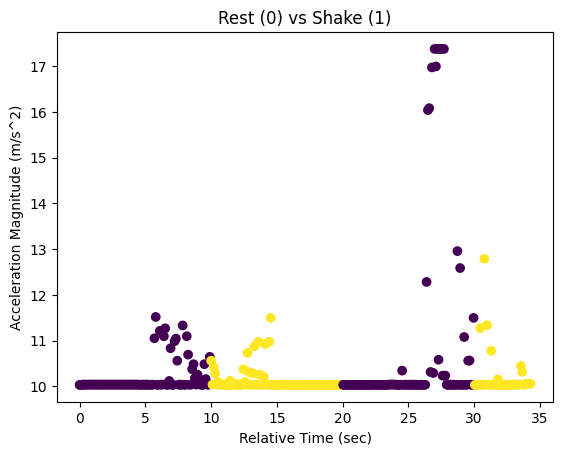

In [20]:
# ============================================================
# CELL 10: Visualization
# ============================================================

plt.figure()
plt.scatter(data["t_rel"], data["magnitude"], c=data["label"])
plt.xlabel("Relative Time (sec)")
plt.ylabel("Acceleration Magnitude (m/s^2)")
plt.title("Rest (0) vs Shake (1)")
plt.show()
